In [1]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

# import libraries:
import sys, os
#os.environ['TF_USE_LEGACY_KERAS'] = '1'  # needed for tensorflow KERAS compatibility
os.environ['DISPLAY'] = 'inline'  # hack to get getdist working
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'../..')))
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import GaussianND
import getdist
getdist.chains.print_load_details = False
import scipy
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# tensorflow imports:
import tensorflow as tf
import tensorflow_probability as tfp

# import the tensiometer tools that we need:
import tensiometer
from tensiometer.utilities import stats_utilities as utilities
from tensiometer.synthetic_probability import synthetic_probability as sp

# getdist settings to ensure consistency of plots:
getdist_settings = {'ignore_rows': 0.3, 
                    'smooth_scale_2D': 0.3,
                    'smooth_scale_1D': 0.3,
                    }    

2025-05-23 20:47:24.339804: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-23 20:47:24.949529: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-23 20:47:24.949697: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-23 20:47:25.088269: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-23 20:47:25.257179: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-23 20:47:25.259219: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
# ADD MY CHAINS:
# Loading samples
#PLANCK_ALL
#lcdm:
chain_lcdm = os.path.join('/home/andrewcats/tesi_magistrale/lcdm/planck_all', '1_lcdm_planck_desidr2_des')
samples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]
print(param_names_lcdm)

#w0wacdm:
chain_w0wa = os.path.join('/home/andrewcats/tesi_magistrale/w0wacdm/all_planck', '1_w0wa_planck_desidr2_des')
samples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]
print(param_names_w0wa)

#EFT_exp:
chain_exp = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/planck_all', '1_EXP_planck_desidr2_des')
samples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_exp = [param.name for param in samples_exp.paramNames.names]
print(param_names_exp)

'''
#ACT_ALL
#lcdm:
chain_lcdm = os.path.join('/home/andrewcats/tesi_magistrale/lcdm/act_all', '1_lcdm_act_planck_desidr2_des')
samples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]
print(param_names_lcdm)

#w0wacdm:
chain_w0wa = os.path.join('/home/andrewcats/tesi_magistrale/w0wacdm/act_all', '1_w0wa_act_planck_desidr2_des')
samples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]
print(param_names_w0wa)

#EFT_exp:
chain_exp = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/act_all', '1_EXP_act_planck_desidr2_des')
samples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_exp = [param.name for param in samples_exp.paramNames.names]
print(param_names_exp)
'''

['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8', 's8h5', 's8omegamp5', 's8omegamp25', 'rdrag', 'beta_dusty', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE']
['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'w', 'wa', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8'

"\n#ACT_ALL\n#lcdm:\nchain_lcdm = os.path.join('/home/andrewcats/tesi_magistrale/lcdm/act_all', '1_lcdm_act_planck_desidr2_des')\nsamples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings=getdist_settings)\n#print('Parameters: ', samples.paramNames.names)\nparam_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]\nprint(param_names_lcdm)\n\n#w0wacdm:\nchain_w0wa = os.path.join('/home/andrewcats/tesi_magistrale/w0wacdm/act_all', '1_w0wa_act_planck_desidr2_des')\nsamples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings=getdist_settings)\n#print('Parameters: ', samples.paramNames.names)\nparam_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]\nprint(param_names_w0wa)\n\n#EFT_exp:\nchain_exp = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/act_all', '1_EXP_act_planck_desidr2_des')\nsamples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings=getdist_settings)

In [3]:
'''
kwargs = {
          'feedback': 2,
          'plot_every': 1000,
          'pop_size': 1,
          #'cache_dir': 'test',  # set this to a directory to cache the results
          #'root_name': 'test',  # sets the name of the flow for the cache files
        }

flow_lcdm = sp.flow_from_chain(samples_lcdm,  # parameter difference chain
                          **kwargs)

flow_w0wa = sp.flow_from_chain(samples_w0wa,  # parameter difference chain
                          **kwargs)

flow_exp = sp.flow_from_chain(samples_exp,  # parameter difference chain
                          **kwargs)
'''

"\nkwargs = {\n          'feedback': 2,\n          'plot_every': 1000,\n          'pop_size': 1,\n          #'cache_dir': 'test',  # set this to a directory to cache the results\n          #'root_name': 'test',  # sets the name of the flow for the cache files\n        }\n\nflow_lcdm = sp.flow_from_chain(samples_lcdm,  # parameter difference chain\n                          **kwargs)\n\nflow_w0wa = sp.flow_from_chain(samples_w0wa,  # parameter difference chain\n                          **kwargs)\n\nflow_exp = sp.flow_from_chain(samples_exp,  # parameter difference chain\n                          **kwargs)\n"

In [4]:
'''
# we can plot training summaries to make sure training went smoothly:
flow_lcdm.training_plot()

flow_w0wa.training_plot()

flow_exp.training_plot()
'''

'\n# we can plot training summaries to make sure training went smoothly:\nflow_lcdm.training_plot()\n\nflow_w0wa.training_plot()\n\nflow_exp.training_plot()\n'

In [5]:
'''
# and we can print the training summary:
flow_lcdm.print_training_summary()

flow_w0wa.print_training_summary()

flow_exp.print_training_summary()
'''

'\n# and we can print the training summary:\nflow_lcdm.print_training_summary()\n\nflow_w0wa.print_training_summary()\n\nflow_exp.print_training_summary()\n'

In [6]:
'''
# we can triangle plot the flow to see how well it has learned the target distribution:
g_lcdm = plots.get_subplot_plotter()
g_lcdm.triangle_plot([samples_lcdm, flow_lcdm.MCSamples(20000)], 
                params=flow_lcdm.param_names,
                filled=True)

g_w0wa = plots.get_subplot_plotter()
g_w0wa.triangle_plot([samples_w0wa, flow_w0wa.MCSamples(20000)], 
                params=flow_w0wa.param_names,
                filled=True)

g_exp = plots.get_subplot_plotter()
g_exp.triangle_plot([samples_exp, flow_exp.MCSamples(20000)], 
                params=flow_exp.param_names,
                filled=True)
'''

'\n# we can triangle plot the flow to see how well it has learned the target distribution:\ng_lcdm = plots.get_subplot_plotter()\ng_lcdm.triangle_plot([samples_lcdm, flow_lcdm.MCSamples(20000)], \n                params=flow_lcdm.param_names,\n                filled=True)\n\ng_w0wa = plots.get_subplot_plotter()\ng_w0wa.triangle_plot([samples_w0wa, flow_w0wa.MCSamples(20000)], \n                params=flow_w0wa.param_names,\n                filled=True)\n\ng_exp = plots.get_subplot_plotter()\ng_exp.triangle_plot([samples_exp, flow_exp.MCSamples(20000)], \n                params=flow_exp.param_names,\n                filled=True)\n'

Re-do:

In [7]:
'''
# this looks nice but not perfect, let's train for longer:
flow_lcdm.feedback = 1
flow_lcdm.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar

flow_w0wa.feedback = 1
flow_w0wa.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar

flow_exp.feedback = 1
flow_exp.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar
'''

"\n# this looks nice but not perfect, let's train for longer:\nflow_lcdm.feedback = 1\nflow_lcdm.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar\n\nflow_w0wa.feedback = 1\nflow_w0wa.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar\n\nflow_exp.feedback = 1\nflow_exp.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar\n"

In [8]:
# we can plot training summaries to make sure training went smoothly:
#flow_lcdm.training_plot()

In [9]:
#flow_w0wa.training_plot()

In [10]:
#flow_exp.training_plot()

In [11]:
'''
# we can triangle plot the flow to see how well it has learned the target distribution:
g_lcdm = plots.get_subplot_plotter()
g_lcdm.triangle_plot([samples_lcdm, 
                 flow_lcdm.MCSamples(20000)  # this flow method returns a MCSamples object
                 ], 
                params=flow_lcdm.param_names,
                filled=True)

g_w0wa = plots.get_subplot_plotter()
g_w0wa.triangle_plot([samples_w0wa, 
                 flow_w0wa.MCSamples(20000)  # this flow method returns a MCSamples object
                 ], 
                params=flow_w0wa.param_names,
                filled=True)

g_exp = plots.get_subplot_plotter()
g_exp.triangle_plot([samples_exp, 
                 flow_exp.MCSamples(20000)  # this flow method returns a MCSamples object
                 ], 
                params=flow_exp.param_names,
                filled=True)
'''

'\n# we can triangle plot the flow to see how well it has learned the target distribution:\ng_lcdm = plots.get_subplot_plotter()\ng_lcdm.triangle_plot([samples_lcdm, \n                 flow_lcdm.MCSamples(20000)  # this flow method returns a MCSamples object\n                 ], \n                params=flow_lcdm.param_names,\n                filled=True)\n\ng_w0wa = plots.get_subplot_plotter()\ng_w0wa.triangle_plot([samples_w0wa, \n                 flow_w0wa.MCSamples(20000)  # this flow method returns a MCSamples object\n                 ], \n                params=flow_w0wa.param_names,\n                filled=True)\n\ng_exp = plots.get_subplot_plotter()\ng_exp.triangle_plot([samples_exp, \n                 flow_exp.MCSamples(20000)  # this flow method returns a MCSamples object\n                 ], \n                params=flow_exp.param_names,\n                filled=True)\n'

This is now much better

In [12]:
'''
ev_lcdm, eer_lcdm = flow_lcdm.evidence(weighted=True)
print(f'LCDM: log(Z) = {ev_lcdm} +- {eer_lcdm}')

ev_w0wa, eer_w0wa = flow_w0wa.evidence(weighted=True)
print(f'W0WA: log(Z) = {ev_w0wa} +- {eer_w0wa}')

ev_exp, eer_exp = flow_exp.evidence(weighted=True)
print(f'EXP: log(Z) = {ev_exp} +- {eer_exp}')
'''

"\nev_lcdm, eer_lcdm = flow_lcdm.evidence(weighted=True)\nprint(f'LCDM: log(Z) = {ev_lcdm} +- {eer_lcdm}')\n\nev_w0wa, eer_w0wa = flow_w0wa.evidence(weighted=True)\nprint(f'W0WA: log(Z) = {ev_w0wa} +- {eer_w0wa}')\n\nev_exp, eer_exp = flow_exp.evidence(weighted=True)\nprint(f'EXP: log(Z) = {ev_exp} +- {eer_exp}')\n"

# FARLO CON AVERAGE 

In [14]:
kwargs = {
          'feedback': 1,
          'verbose': -1,
          'plot_every': 1000,
          'pop_size': 1,
          'num_flows': 5,
          'epochs': 400,
        }

average_flow_lcdm = sp.average_flow_from_chain(samples_lcdm,  # parameter difference chain
                                          **kwargs)

Training flow 0


/home/andrewcats/anaconda3/envs/tensiometer_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 400/400 [12:05<00:00,  1.81s/epoch, loss=28.4, val_loss=29.3, lr=0.001]


Training flow 1


100%|██████████| 400/400 [10:38<00:00,  1.60s/epoch, loss=28.4, val_loss=29.3, lr=0.001]


Training flow 2


100%|██████████| 400/400 [11:07<00:00,  1.67s/epoch, loss=28.4, val_loss=29.3, lr=0.001]


Training flow 3


100%|██████████| 400/400 [10:57<00:00,  1.64s/epoch, loss=28.4, val_loss=29.3, lr=0.001]


Training flow 4


100%|██████████| 400/400 [10:54<00:00,  1.64s/epoch, loss=28.4, val_loss=29.3, lr=0.001]


In [16]:
average_flow_w0wa = sp.average_flow_from_chain(samples_w0wa,  # parameter difference chain
                                          **kwargs)

Training flow 0


100%|██████████| 400/400 [17:00<00:00,  2.55s/epoch, loss=30.6, val_loss=32.4, lr=3.16e-5]


Training flow 1


100%|██████████| 400/400 [09:14<00:00,  1.39s/epoch, loss=30.6, val_loss=32.3, lr=0.0001]


Training flow 2


100%|██████████| 400/400 [09:18<00:00,  1.40s/epoch, loss=30.8, val_loss=32.4, lr=3.16e-5]


Training flow 3


100%|██████████| 400/400 [09:25<00:00,  1.41s/epoch, loss=31, val_loss=32.4, lr=3.16e-5]


Training flow 4


100%|██████████| 400/400 [09:28<00:00,  1.42s/epoch, loss=30.9, val_loss=32.4, lr=1e-5]


In [17]:
average_flow_exp = sp.average_flow_from_chain(samples_exp,  # parameter difference chain
                                          **kwargs)

Training flow 0


 96%|█████████▋| 386/400 [08:15<00:17,  1.28s/epoch, loss=30.1, val_loss=31.1, lr=1e-6]


Training flow 1


100%|██████████| 400/400 [08:34<00:00,  1.29s/epoch, loss=30.1, val_loss=31, lr=1e-6]


Training flow 2


 98%|█████████▊| 392/400 [08:21<00:10,  1.28s/epoch, loss=30.1, val_loss=31.1, lr=1e-6]


Training flow 3


 95%|█████████▍| 379/400 [09:07<00:30,  1.44s/epoch, loss=30.2, val_loss=31, lr=1e-6]


Training flow 4


100%|██████████| 400/400 [19:58<00:00,  3.00s/epoch, loss=30.1, val_loss=31.1, lr=1e-6]


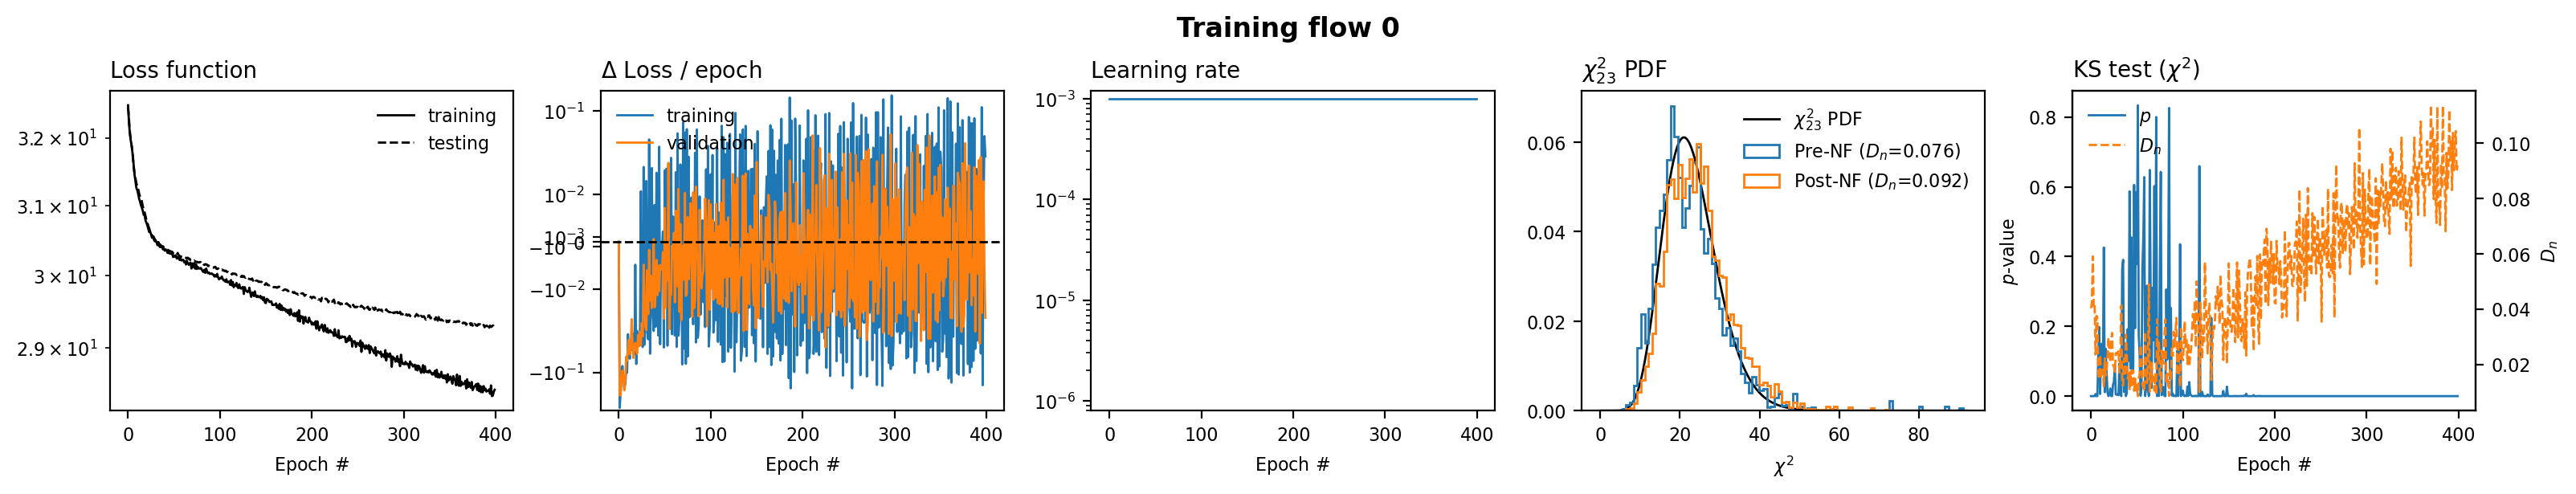

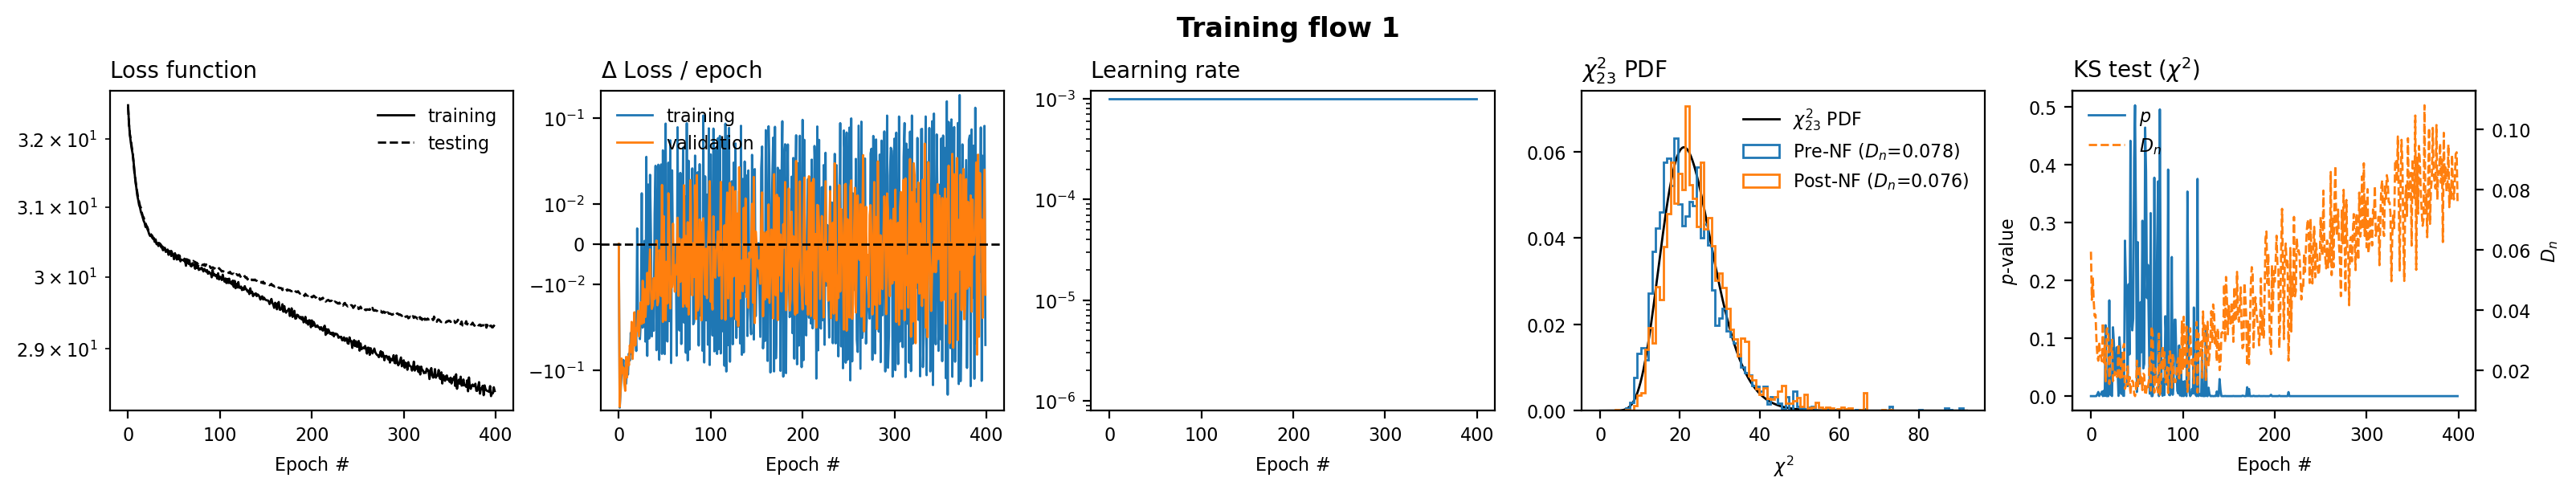

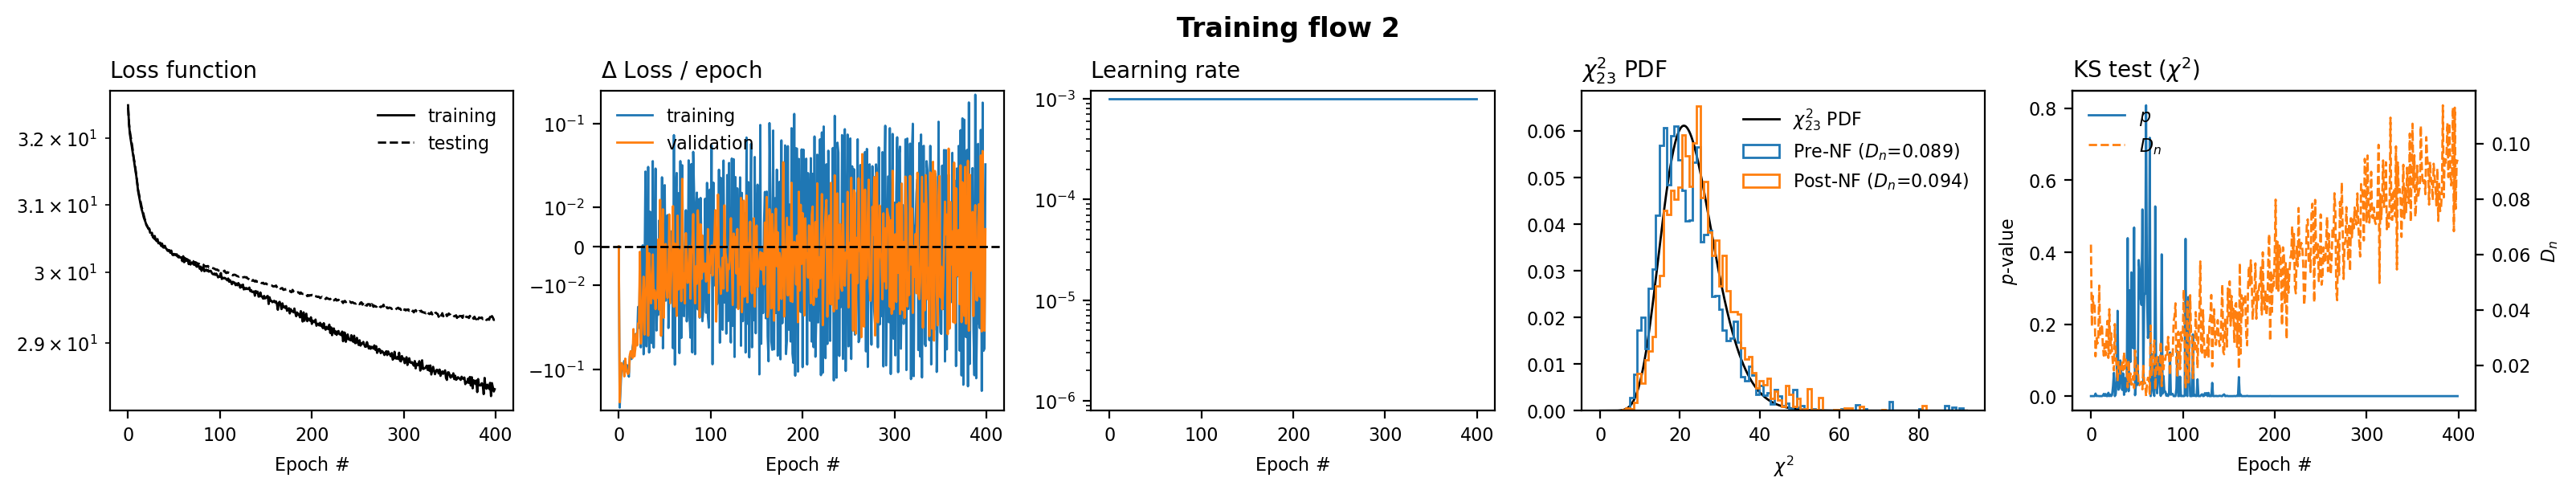

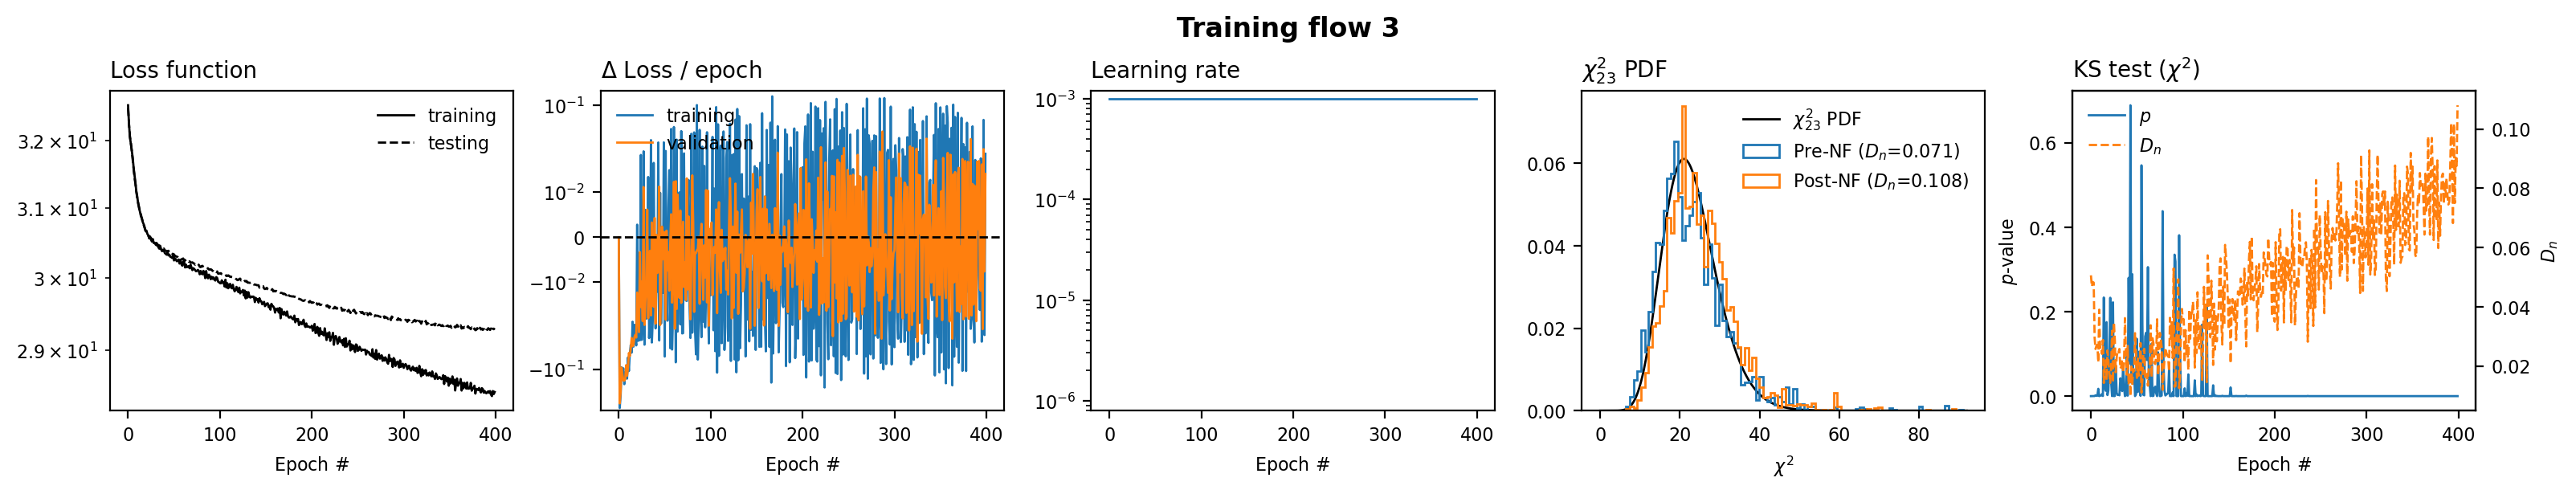

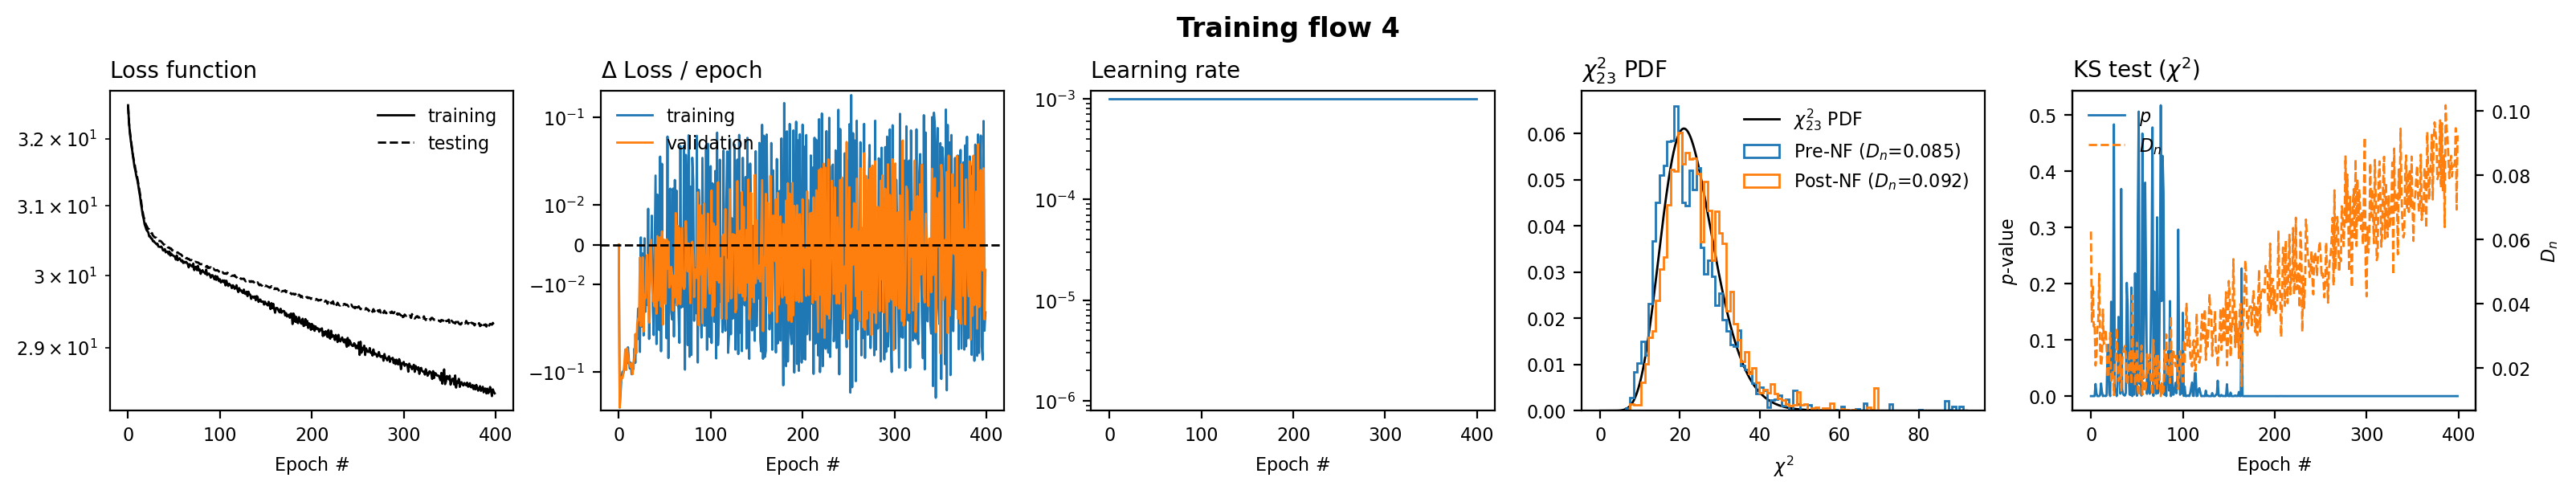

In [18]:
# most methods are implemented for the average flow as well:
average_flow_lcdm.training_plot()

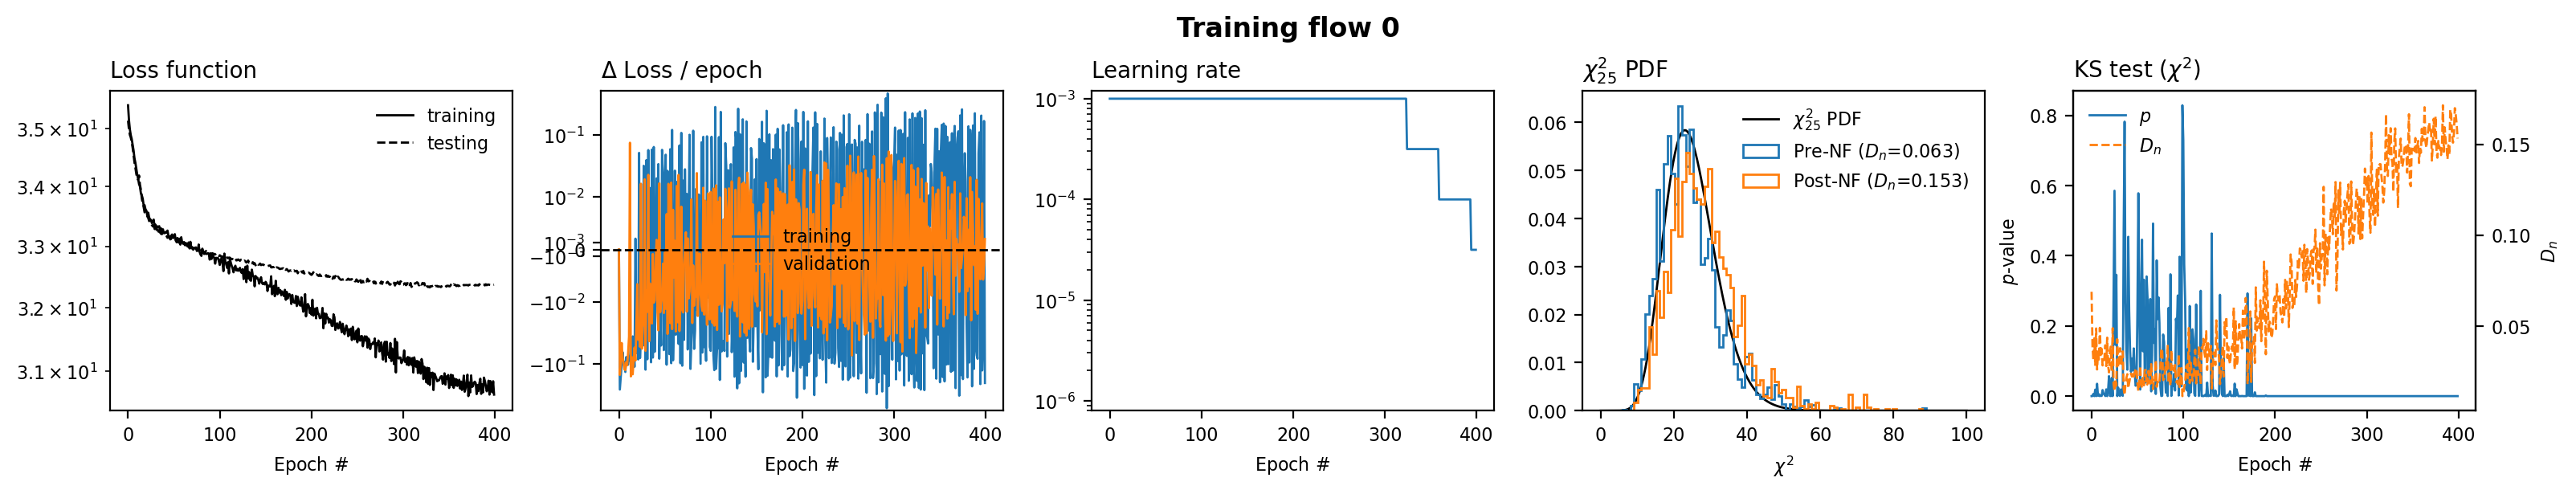

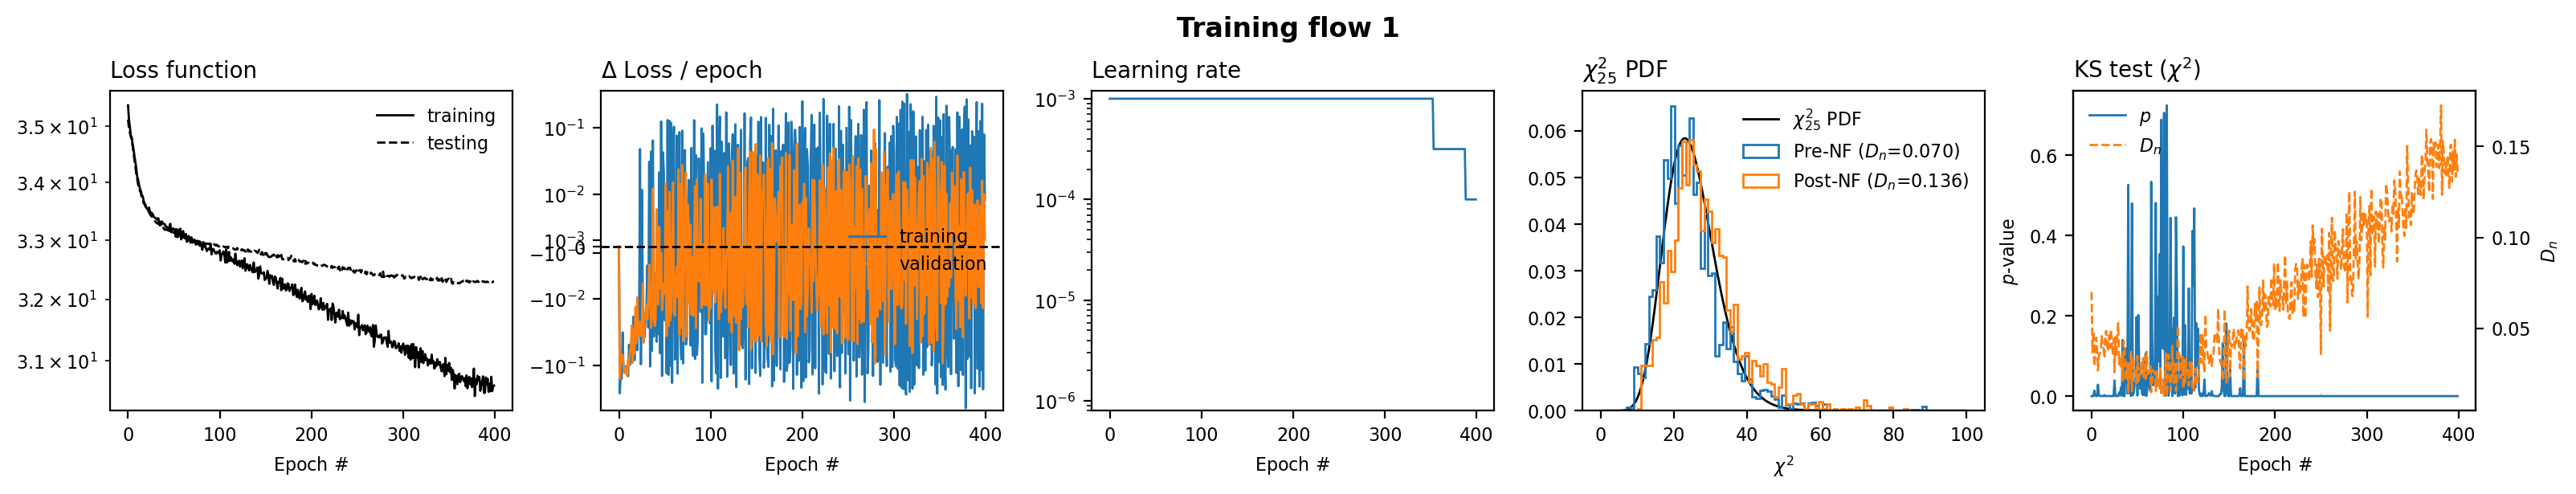

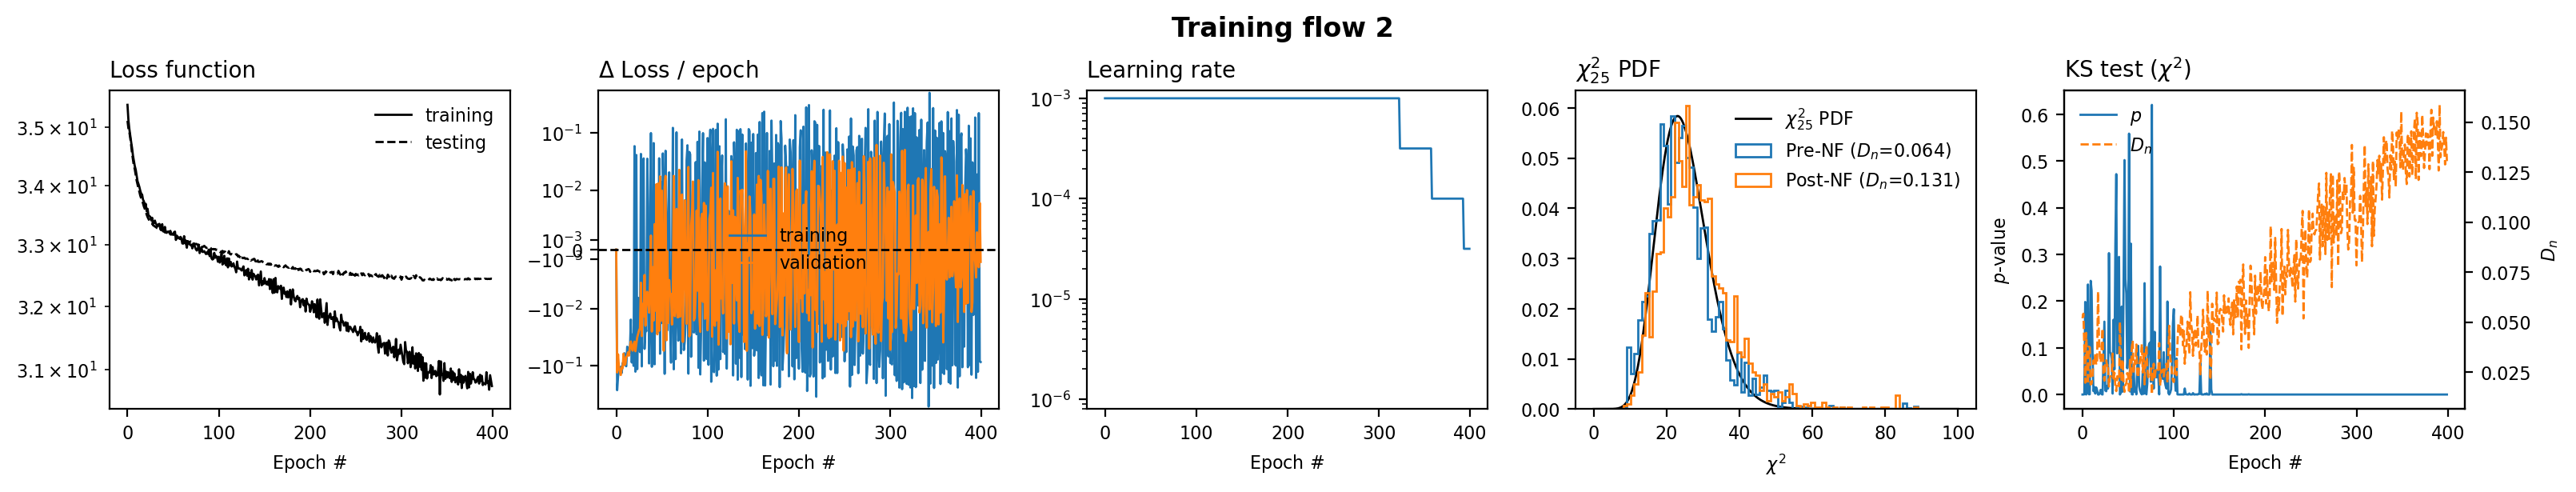

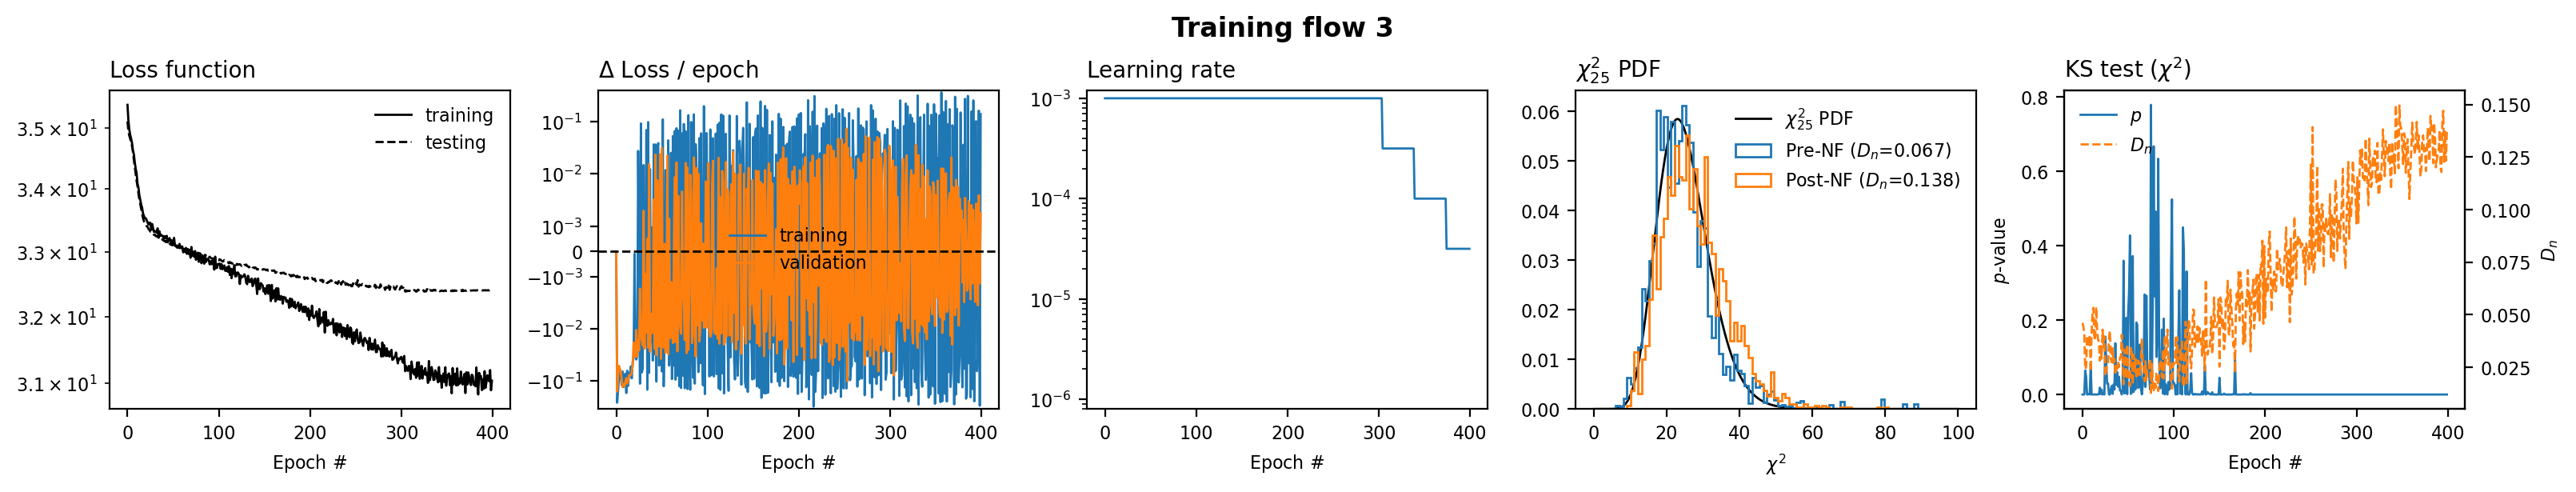

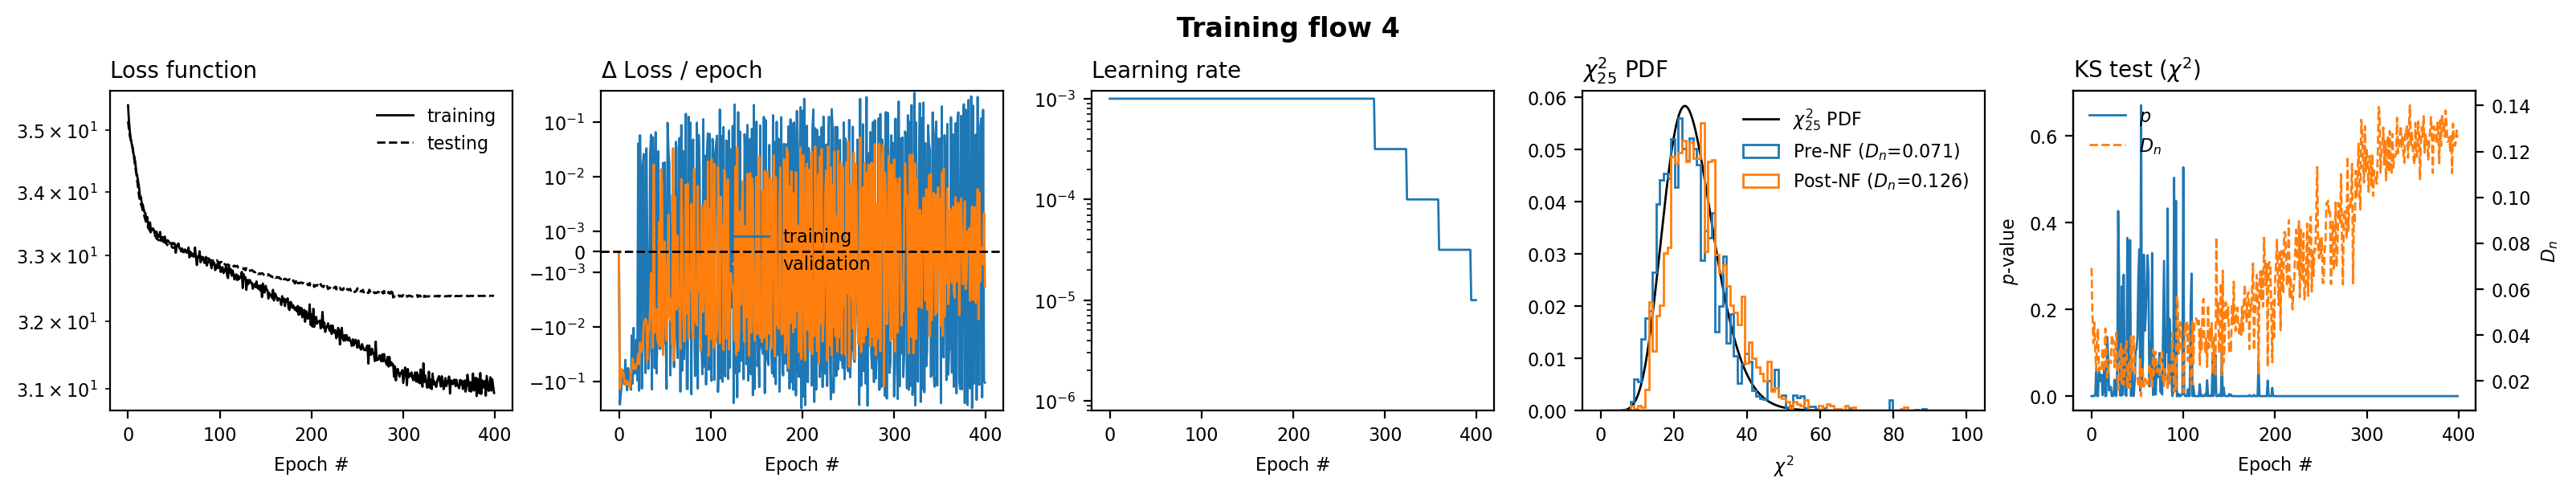

In [19]:
# most methods are implemented for the average flow as well:
average_flow_w0wa.training_plot()

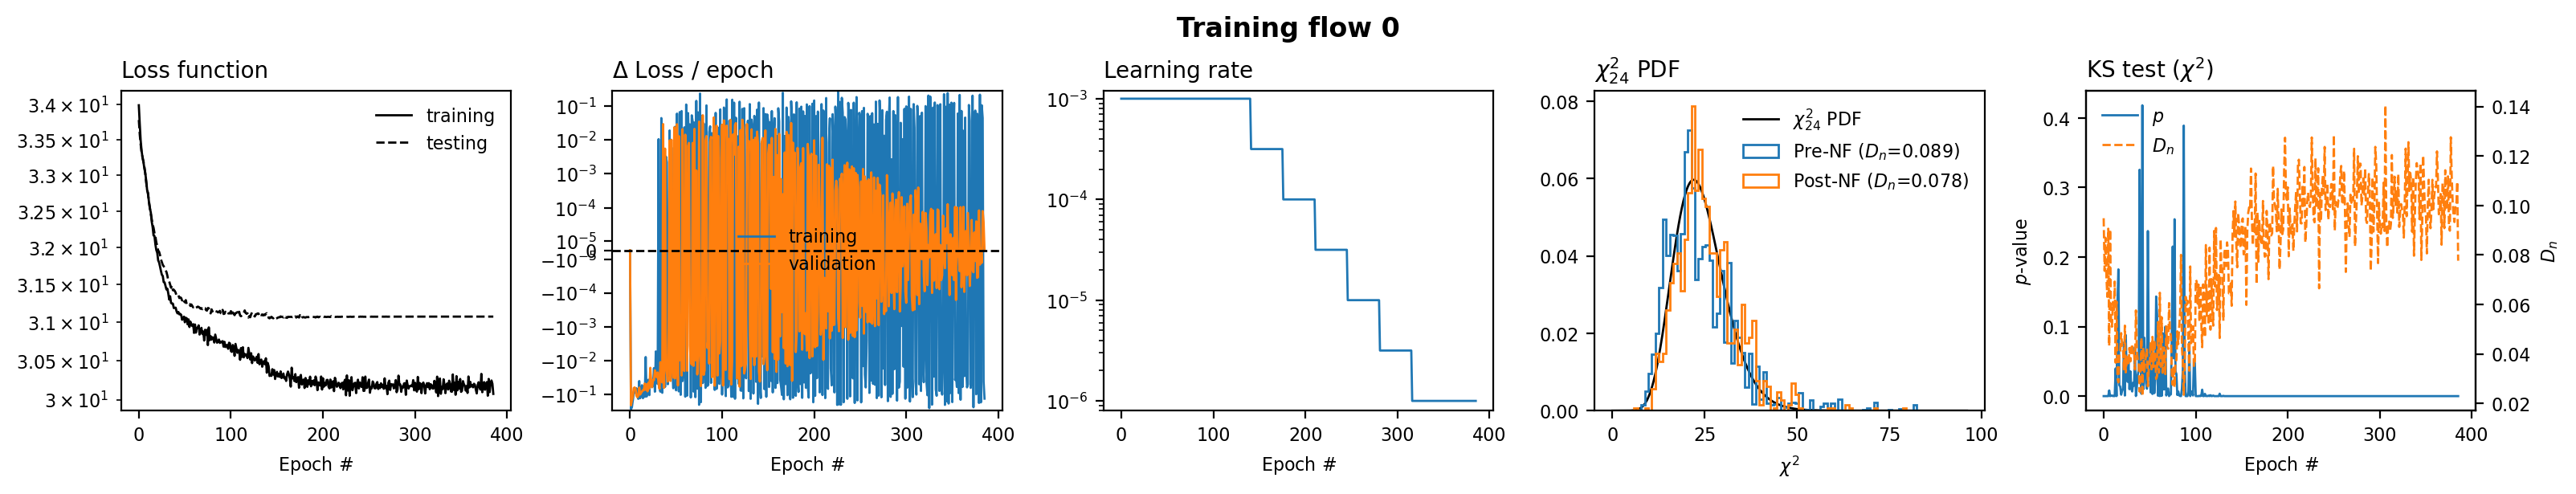

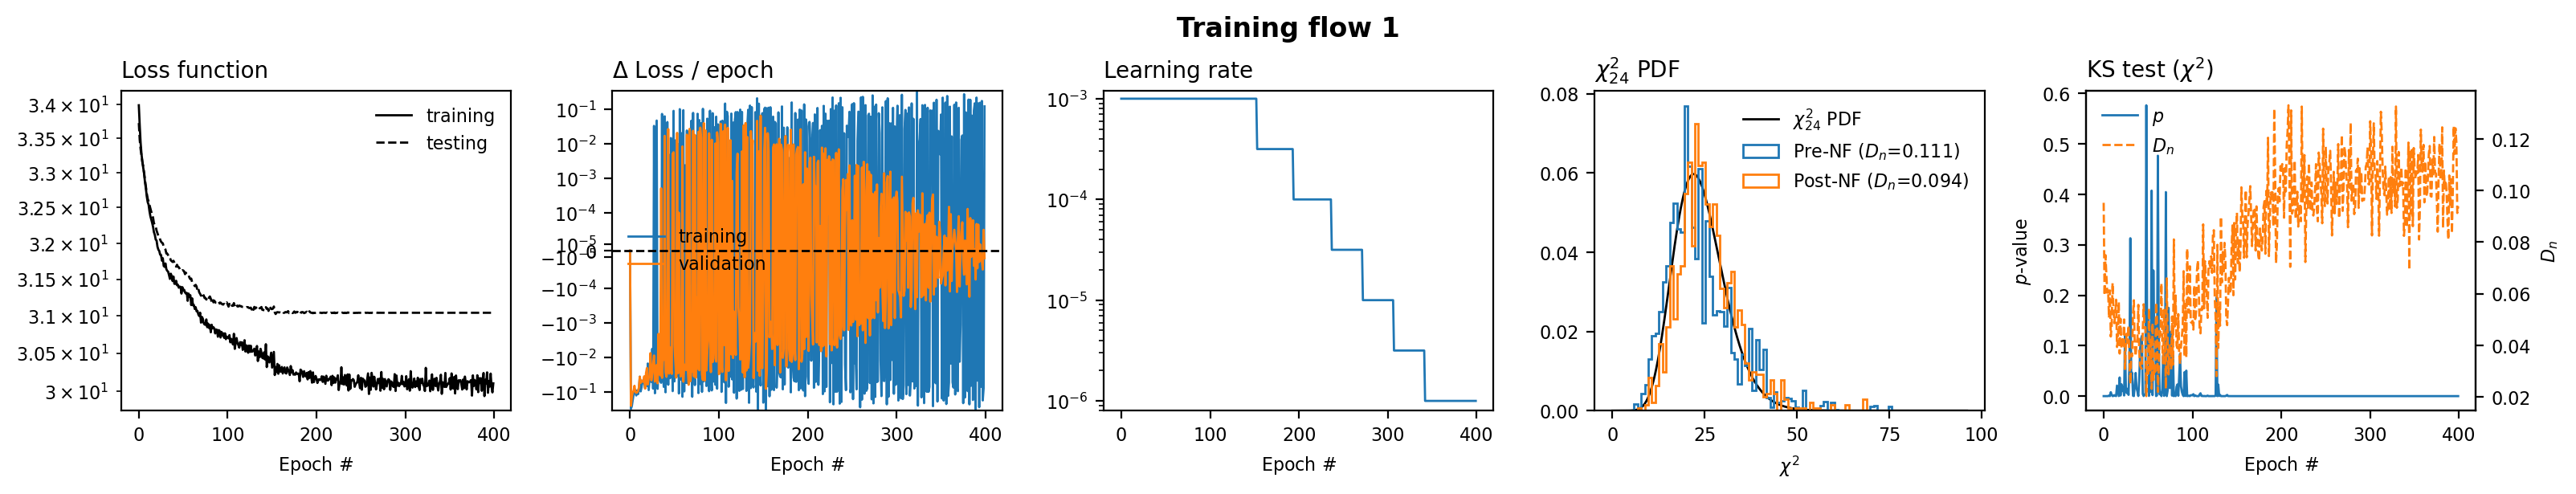

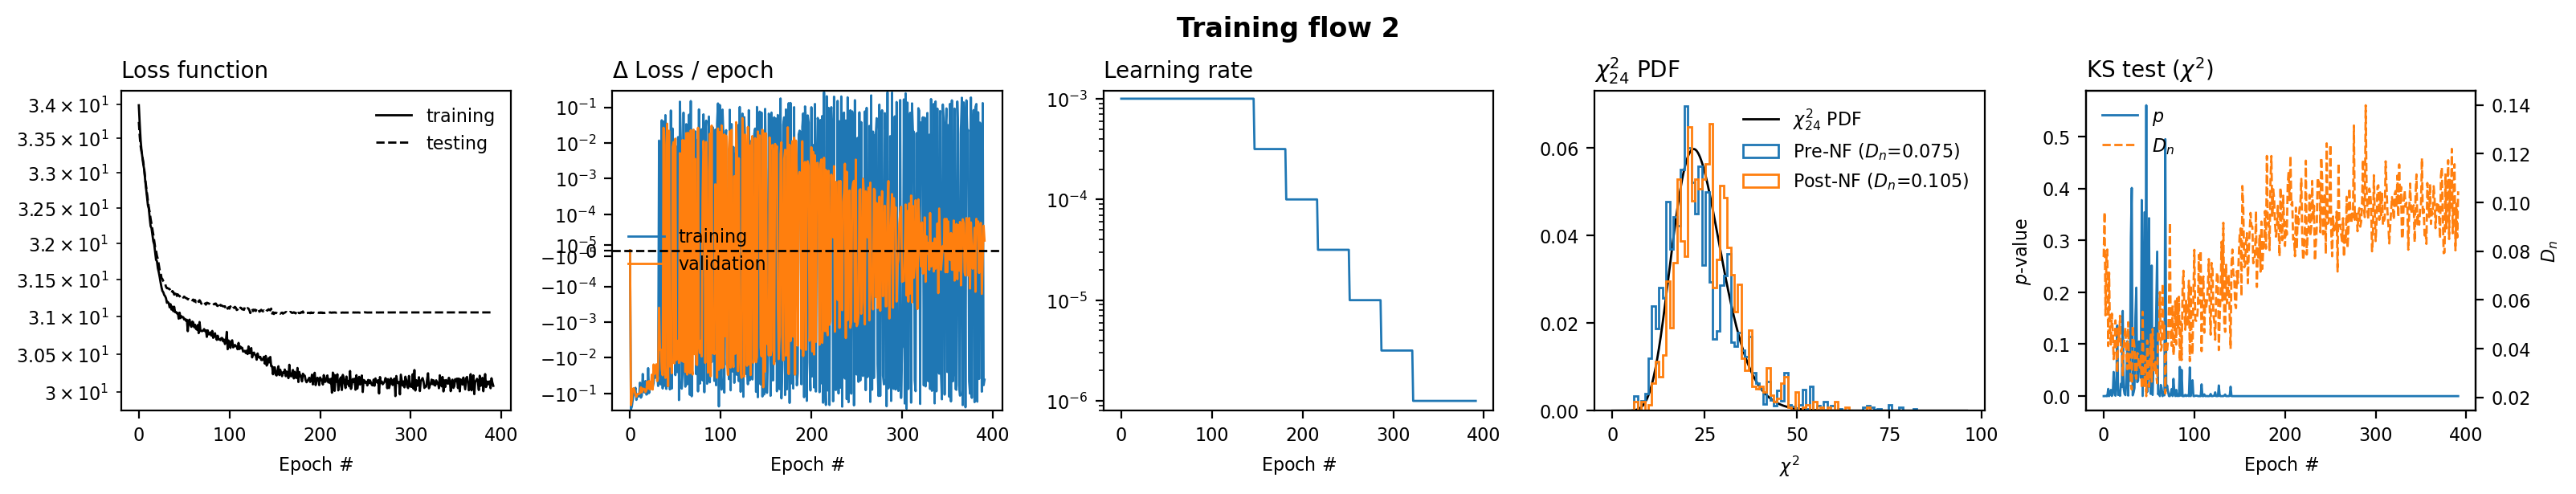

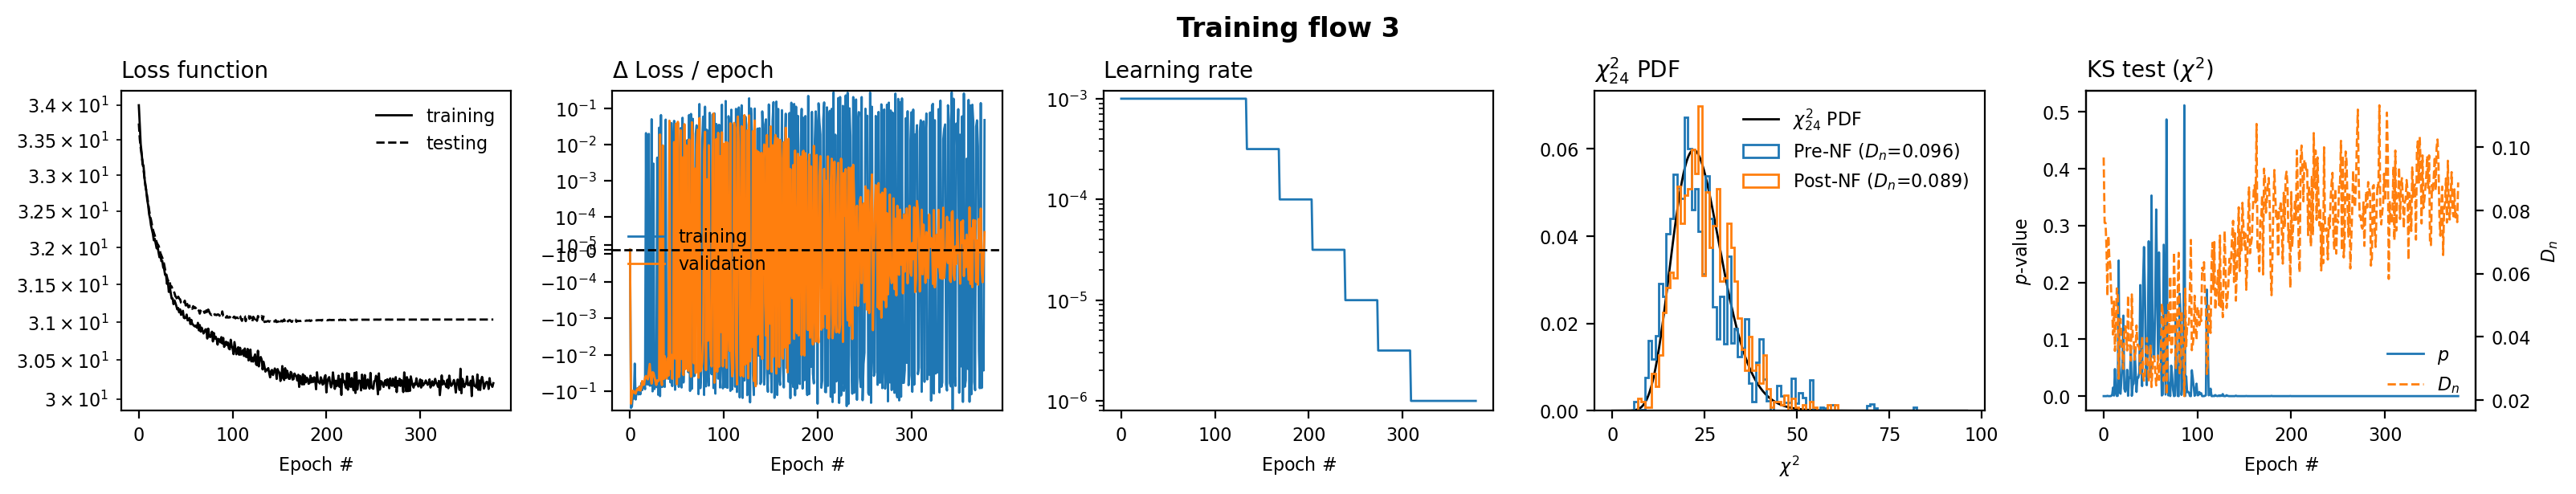

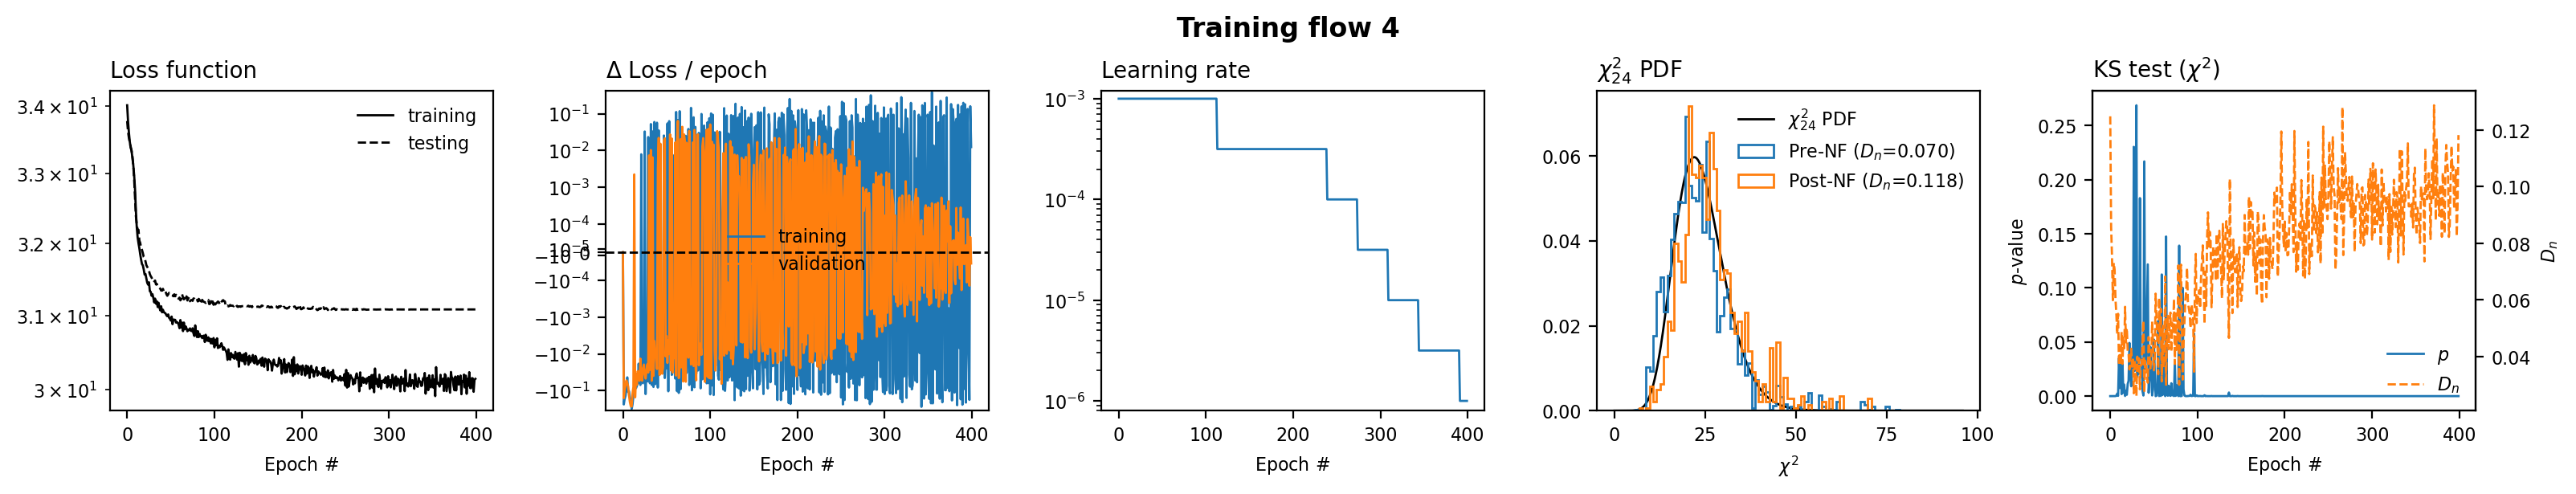

In [20]:
# most methods are implemented for the average flow as well:
average_flow_exp.training_plot()

In [21]:
# and we can print the training summary, which in this case contains more info:
average_flow_lcdm.print_training_summary()

Number of flows: 5
Flow weights   : [0.21 0.2  0.2  0.2  0.2 ]
loss         : [28.43 28.43 28.36 28.44 28.38]
val_loss     : [29.27 29.31 29.33 29.3  29.31]
lr           : [0. 0. 0. 0. 0.]
chi2Z_ks     : [0.09 0.08 0.09 0.11 0.09]
chi2Z_ks_p   : [6.34e-39 1.19e-26 7.02e-41 9.46e-54 2.36e-39]
loss_rate    : [ 0.03 -0.05  0.03  0.03 -0.02]
val_loss_rate: [-0.02 -0.01  0.    0.02 -0.01]


In [22]:
# and we can print the training summary, which in this case contains more info:
average_flow_w0wa.print_training_summary()

Number of flows: 5
Flow weights   : [0.2  0.22 0.19 0.2  0.2 ]
loss         : [30.64 30.6  30.75 31.04 30.94]
val_loss     : [32.37 32.3  32.45 32.4  32.38]
lr           : [3.16e-05 1.00e-04 3.16e-05 3.16e-05 1.00e-05]
chi2Z_ks     : [0.15 0.14 0.13 0.14 0.13]
chi2Z_ks_p   : [8.38e-61 5.92e-48 3.14e-44 3.17e-49 2.71e-41]
loss_rate    : [-0.21  0.01 -0.09  0.14 -0.1 ]
val_loss_rate: [ 0.  0. -0.  0. -0.]


In [23]:
# and we can print the training summary, which in this case contains more info:
average_flow_exp.print_training_summary()

Number of flows: 5
Flow weights   : [0.2  0.2  0.2  0.21 0.2 ]
loss         : [30.07 30.1  30.08 30.2  30.14]
val_loss     : [31.08 31.04 31.06 31.03 31.08]
lr           : [1.e-06 1.e-06 1.e-06 1.e-06 1.e-06]
chi2Z_ks     : [0.08 0.09 0.1  0.09 0.12]
chi2Z_ks_p   : [3.85e-08 1.06e-11 2.07e-14 1.66e-10 2.60e-18]
loss_rate    : [-0.13  0.12 -0.04  0.05  0.01]
val_loss_rate: [ 0.00e+00 -1.14e-05  1.72e-05  4.01e-05 -3.43e-05]


In [ ]:
avg_samples_lcdm = average_flow_lcdm.MCSamples(20000)
avg_samples_lcdm.name_tag = 'Average Flow LCDM'
temp_samples_lcdm = [_f.MCSamples(20000) for _f in average_flow_lcdm.flows]
for i, _s in enumerate(temp_samples_lcdm):
    _s.name_tag = _s.name_tag + f'_{i}'
# let's plot the flows:
g = plots.get_subplot_plotter()
g.triangle_plot([chain_lcdm, avg_samples_lcdm] + temp_samples_lcdm,
                filled=False)

avg_samples_w0wa = average_flow_w0wa.MCSamples(20000)
avg_samples_w0wa.name_tag = 'Average Flow W0WA'
temp_samples_w0wa = [_f.MCSamples(20000) for _f in average_flow_w0wa.flows]
for i, _s in enumerate(temp_samples_w0wa):
    _s.name_tag = _s.name_tag + f'_{i}'
# let's plot the flows:
g = plots.get_subplot_plotter()
g.triangle_plot([chain_w0wa, avg_samples_w0wa] + temp_samples_w0wa,
                filled=False)

avg_samples_exp = average_flow_exp.MCSamples(20000)
avg_samples_exp.name_tag = 'Average Flow EXP'
temp_samples_exp = [_f.MCSamples(20000) for _f in average_flow_exp.flows]
for i, _s in enumerate(temp_samples_exp):
    _s.name_tag = _s.name_tag + f'_{i}'
# let's plot the flows:
g = plots.get_subplot_plotter()
g.triangle_plot([chain_exp, avg_samples_exp] + temp_samples_exp,
                filled=False)

KeyboardInterrupt: 

In [1]:
ev_lcdm, eer_lcdm = average_flow_lcdm.evidence(weighted=True)
print(f'LCDM: log(Z) = {ev_lcdm} +- {eer_lcdm}')

ev_w0wa, eer_w0wa = average_flow_w0wa.evidence(weighted=True)
print(f'W0WA: log(Z) = {ev_w0wa} +- {eer_w0wa}')

ev_exp, eer_exp = average_flow_exp.evidence(weighted=True)
print(f'EXP: log(Z) = {ev_exp} +- {eer_exp}')

NameError: name 'average_flow_lcdm' is not defined